# Exercícios de Regressão Logística e Classificação Binária

#Exercício 1:

A Regressão Logística funciona em duas etapas:


## 1. Parte Linear

Primeiro, o modelo calcula:

$$
z = w_1 x_1 + w_2 x_2 + b
$$

onde:

- $x_1$ e $x_2$ são as entradas (features)  
- $w_1$ e $w_2$ são os pesos  
- $b$ é o bias (ajuste)



## 2. Função Sigmoide

Depois, aplica a função sigmoide:

$$
\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}
$$

Isso transforma o valor em uma **probabilidade entre 0 e 1**.


## Tarefa 1

Suponha que o modelo aprendeu:

- $w_1 = 2.0$  
- $w_2 = -1.0$  
- $b = 0.5$

E temos um ponto:

- $x_1 = 1.2$  
- $x_2 = -0.3$


### a) Calcule o valor de $z$

$$
z = w_1 x_1 + w_2 x_2 + b
$$


### b) Calcule a probabilidade

$$
\hat{y} = \frac{1}{1 + e^{-z}}
$$


### c) Classificação final

- Se $\hat{y} > 0.5$ → Classe 1  
- Caso contrário → Classe 0  



## Tarefa 2

Responda com suas próprias palavras:

1. O que representam $w_1$ e $w_2$?  
2. Qual o papel do $b$?  
3. Por que usamos a função sigmoide?

Dica:

- $w$ → importância de cada variável  
- $b$ → ajuste da linha  
- Sigmoide → transforma em probabilidade  

In [3]:
import numpy as np
#pesos e bias
w1 = 2
w2 = -1
b = 0.5

# atributos
x1 = 1.2
x2 = -0.3

#calculo de z
z = x1*w1 + x2*w2 + b
print(f'z= {z}')

#funcao sigmoide para calcular a probabilidade
y_hat = 1/(1+np.exp(-z))
print(f'y_hat= {y_hat}')

#probabilidade de pertencer a classe 1
if y_hat > 0.5:
  print('Classe 1')
else:
  print('Classe 0')

z= 3.1999999999999997
y_hat= 0.9608342772032357
Classe 1


w1 e w2 são os pesos associados aos atributos x1 e x2 (ponderam a relevancia de cada atributo)

b é o bias, ele desloca a fronteira de decisão (não está associado aos pesos, termo independente)

a função sigmoide é usada para confinar os valores previstos pela regressão entre 0 e 1, transformando a saída em uma probabilidade usada para classificação

# Exercício 2:

Neste exercício, você vai criar um código semelhante ao exemplo visto em aula para treinar um modelo de **Regressão Logística**.


# Tarefa

Implemente um classificador binário seguindo os seguintes dados:

Crie duas classes:

- Classe 0: centrada em (-2, -2)  
- Classe 1: centrada em (2, 2)  

Use distribuição normal para gerar os pontos.

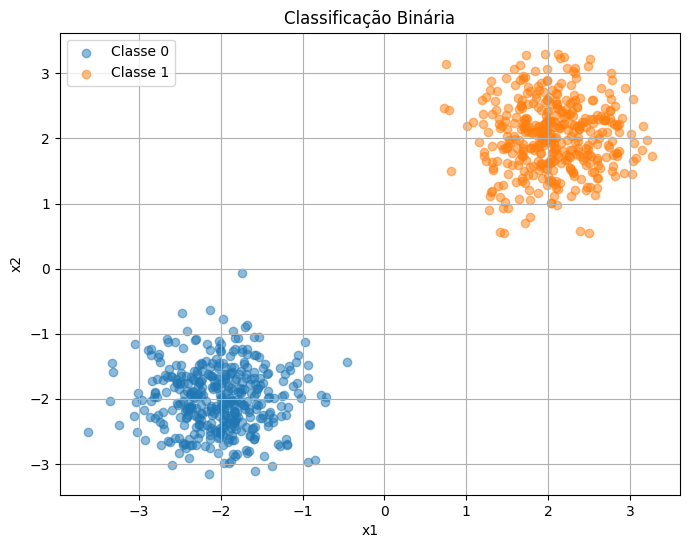

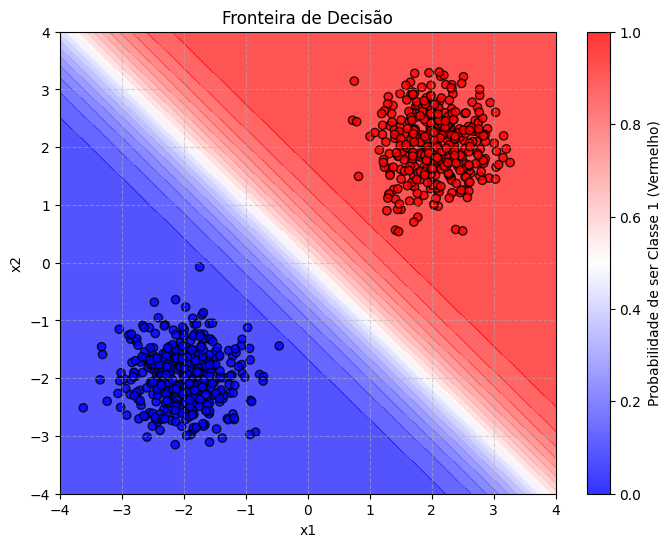

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

np.random.seed(42)

N = 400

# Classe 0
x0 = np.random.randn(N, 2) * 0.5 - 2 #desvio padrao 0.5 e média -2, shape = (400,2)
y0 = np.zeros(N)

# Classe 1
x1 = np.random.randn(N, 2) * 0.5 + 2 #desvio padrao 0.5 e média 2, shape = (400,2)
y1 = np.ones(N)

# Juntar dados
X = np.vstack([x0, x1]) # concatena verticalmente x0 e x1,   shape = (800,2)
y = np.hstack([y0, y1]) # concatena horizontalmente y0 e y1, shape = (800,)

# Separar treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42) # como o dataset é pequeno, separa 10% para teste

# Treinar modelo
model = LogisticRegression()
model.fit(X_train, y_train)

# Predição
y_pred = model.predict(X_test)

# Plot dos dados
plt.figure(figsize=(8,6))

plt.scatter(x0[:,0], x0[:,1], alpha=0.5, label="Classe 0")
plt.scatter(x1[:,0], x1[:,1], alpha=0.5, label="Classe 1")

plt.title("Classificação Binária")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.show()

# Fronteira de decisão

#criando um meshgrid (malha de pontos), necessária para plots 3D (xx e yy tem shape = (200,200))
xx, yy = np.meshgrid(np.linspace(-4, 4, 200),
                     np.linspace(-4, 4, 200))

# transforma xx e yy em vetores coluna (40000,1) e concatena (40000,2) para que fique no formato [x,y] aceito pelo predict_proba
grid = np.c_[xx.ravel(), yy.ravel()]
# predict_proba recebe a matriz de formato [x,y] e retorna as probabilidades da classe 1 [:,1]
probs = model.predict_proba(grid)[:, 1]
# é feito um reshape para que as probabilidades sigam o mesmo formato original do grid (200,200)
probs = probs.reshape(xx.shape)


plt.figure(figsize=(8,6))
# plota a fronteira de decisão com base nas probabilidades associadas às classes. Ou seja, a fronteira é a reta onde as probabilidades são 0 (modelo não consegue decidir)
plt.contourf(xx, yy, probs, levels=20, alpha=0.7, cmap="bwr")
plt.scatter(X[:,0], X[:,1], c=y, edgecolor="k", cmap="bwr", alpha=0.8) # plotando os pontos, com as cores seguindo a classe y

plt.title("Fronteira de Decisão")
plt.xlabel("x1")
plt.ylabel("x2")
plt.colorbar(label="Probabilidade de ser Classe 1 (Vermelho)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Desafio:

Simule um dataset de saúde, onde a probabilidade de risco é dada por uma função logística.

Probabilidade:

$$ p = \frac{1}{1 + e^{-(0.03 \cdot P + 0.02 \cdot C - 10)}} $$

Tarefas
* Simular 700 pacientes.
* Calcular $p$ usando a fórmula acima.
* Gerar a classe $y$.
* Treinar regressão logística.

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Simular pacientes
np.random.seed(42)
X = np.c_[np.random.randn(700,1) * 100, np.random.randn(700,1) + 500] # 700 pacientes com 2 atributos, atributo 1 tem desvio padrão 100 e atributo 2 tem média 500

# 2. Calcular p
p = 1/(1+np.exp(-(0.03*X[:,0]+0.02*X[:,1]-10)))

# 3. Criar classes
# usando a fórmula conhecida para criar as classes
y = (p>0.5).astype(int) # quando a probabilidade é menor que 0.5 cria a classe 0 e quando a probabilidade é maior que 0.5 cria a classe 1

# 4. Treinar modelo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


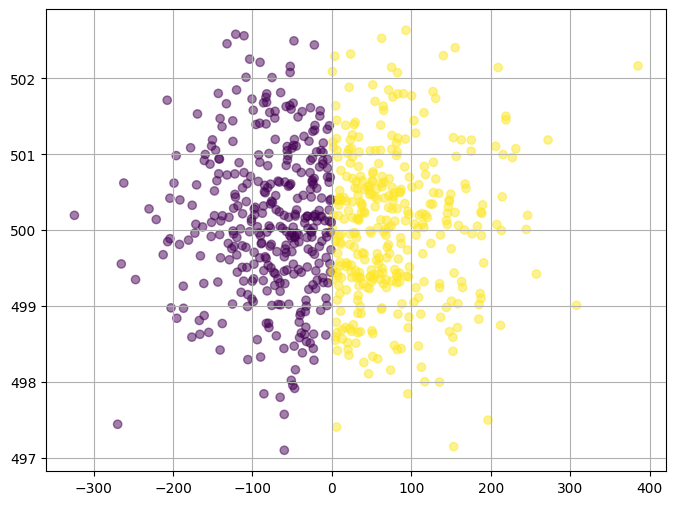

In [35]:
plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], alpha=0.5, c=y)
plt.grid(True)
plt.show()

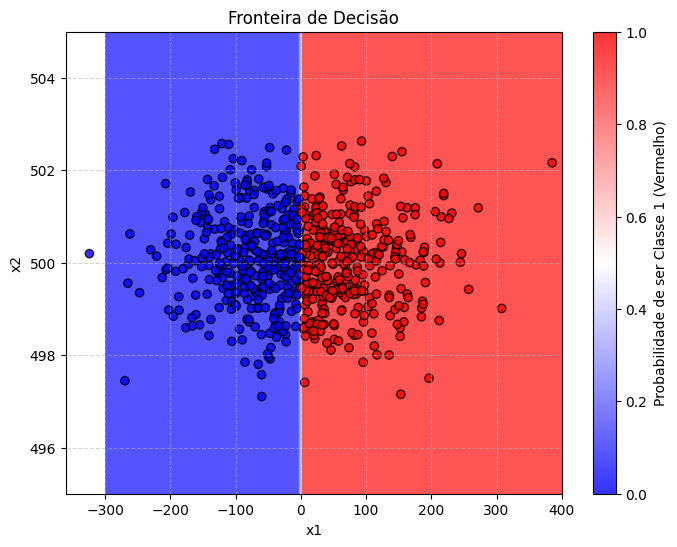

In [39]:
# Fronteira de decisão

#criando um meshgrid (malha de pontos), necessária para plots 3D (xx e yy tem shape = (200,200))
xx, yy = np.meshgrid(np.linspace(-300, 400, 200),
                     np.linspace(495, 505, 200))

# transforma xx e yy em vetores coluna (40000,1) e concatena (40000,2) para que fique no formato [x,y] aceito pelo predict_proba
grid = np.c_[xx.ravel(), yy.ravel()]
# predict_proba recebe a matriz de formato [x,y] e retorna as probabilidades da classe 1 [:,1]
probs = model.predict_proba(grid)[:, 1]
# é feito um reshape para que as probabilidades sigam o mesmo formato original do grid (200,200)
probs = probs.reshape(xx.shape)


plt.figure(figsize=(8,6))
# plota a fronteira de decisão com base nas probabilidades associadas às classes. Ou seja, a fronteira é a reta onde as probabilidades são 0 (modelo não consegue decidir)
plt.contourf(xx, yy, probs, levels=20, alpha=0.7, cmap="bwr")
plt.scatter(X[:,0], X[:,1], c=y, edgecolor="k", cmap="bwr", alpha=0.8) # plotando os pontos, com as cores seguindo a classe y

plt.title("Fronteira de Decisão")
plt.xlabel("x1")
plt.ylabel("x2")
plt.colorbar(label="Probabilidade de ser Classe 1 (Vermelho)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()